In [1]:
import pandas as pd
import numpy as np
import datetime
from matplotlib import pyplot as plt
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units
import metpy.constants as mpconst
from scipy.signal import argrelextrema
from scipy.signal import find_peaks
from matplotlib  import cm

In [2]:
# Extra plotting
import matplotlib.ticker as mticker
from windrose import WindroseAxes, plot_windrose

import seaborn as sns

In [3]:
#Define start dates here
tstart = datetime.datetime(2026, 3, 31, 5, 0, 0)
tend = datetime.datetime(2026, 3, 31, 12, 0, 0)

# Start time for 30 minute sweep analysis (local time)
start_time = pd.Timestamp('2026-03-31 07:00:00')
date_str = '2026-03-30 '
date_str2 = '2026-03-31 '

# Dataset 1: The measurements from the weather balloons

## Data Processing

When we obtain raw data, it's often not in the ideal format for analysis.  
In this section, we process the data to make it easier to work with. This includes:

* Renaming columns and removing any unnecessary fields  
* Converting time strings (just plain text) into time objects (Python recognizes as actual dates and times)
* Adjusting time from UTC to local time  


In [4]:
def convert_utc_times(times,date_str,date_str2):
    """
    Convert a list of time strings (in UTC) to full datetime objects in UTC.
    
    Times from 19:00:00 and later are treated as March 24,
    and earlier times as March 25.
    """
    datetime_strings = []
    for t in times:
        hour = int(t.split(':')[0])
        if hour >= 19:
            datetime_strings.append(date_str + t)
        else:
            datetime_strings.append(date_str2 + t)

    # Convert to datetime objects (still in UTC)
    datetimes_utc = pd.to_datetime(datetime_strings, format='%Y-%m-%d %H:%M:%S')
    
    return datetimes_utc

In [5]:
new_column_names = {
    # Format is 
    # Old name : new name
    'UTC time': 'utc_time',
    ' Altitude (m MSL)': 'height_msl_m',
    ' Altitude (m AGL)': 'height_agl_m',
    ' Pressure (Pascal)': 'pressure',
    ' Speed (m/s)': 'horizontal_speed_mps',
    ' Heading (degrees)': 'heading_deg',
    ' Temperature (C)': 'temperature',
    ' Relative humidity (%)': 'rh',
    ' Internal temperature (C)': 'internal_temp_c',
    ' Latitude': 'latitude',
    ' Longitude': 'longitude',
    ' Rise speed (m/s)': 'vertical_speed_mps',
}

In [6]:
# data
PATH ='2026-03-31_0720.raw_history.csv'



In [7]:

data = pd.read_csv(PATH)



In [8]:
data = (data
         .rename(columns=new_column_names) # Rename the columns
         .drop(columns=['latitude', 'longitude', 'internal_temp_c']) # Remove these columns
        )


In [9]:
data.head()

,utc_time,height_msl_m,height_agl_m,pressure,horizontal_speed_mps,heading_deg,temperature,rh,vertical_speed_mps
0,20:21:00,74,8,101658,,,13.66,87.20,
1,20:21:02,74,8,101660,,,13.65,86.15,
2,20:21:02,74,8,101660,,,13.62,85.80,
3,20:21:03,74,8,101660,,,13.61,85.60,
4,20:21:04,74,8,101660,,,13.59,85.45,


In [10]:
# Add theta to our data
data['theta']  = (data.temperature+273.15) * (100000/data.pressure) ** 0.286 - 273.15


In [11]:
# Convert to UTC datetimes
data['datetimes_utc'] = convert_utc_times(data.utc_time,date_str,date_str2)


In [12]:
# Convert to local time by adding 11 hours
data['datetimes_local'] = [dt + datetime.timedelta(hours=11) for dt in data['datetimes_utc']]


In [13]:
# The row labels (index) are now 'datetimes_local'
data = data.set_index('datetimes_local')


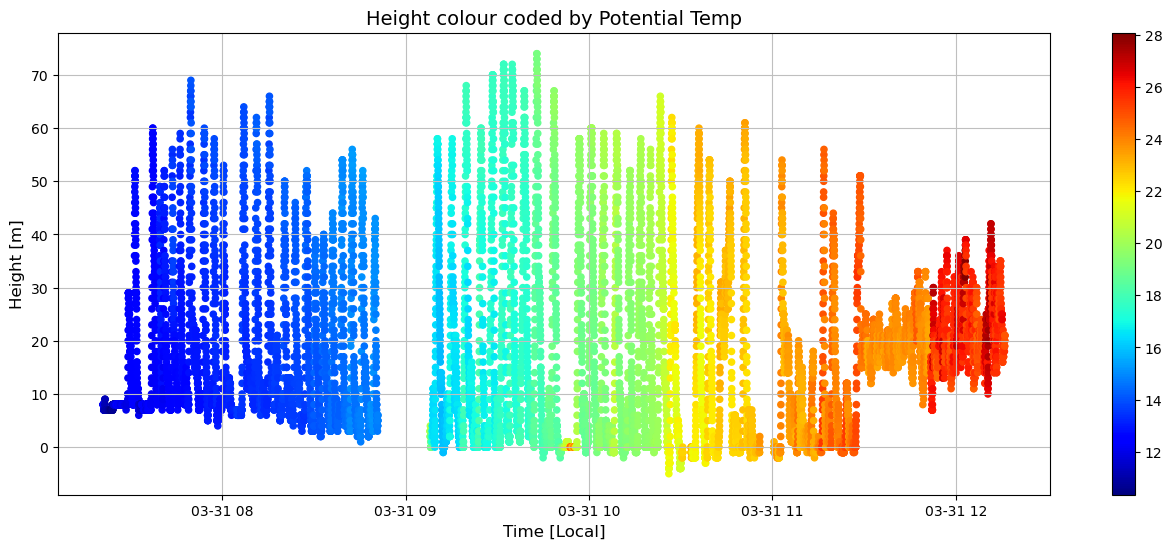

In [14]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values ,data['height_agl_m'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

## Play around with this figure below

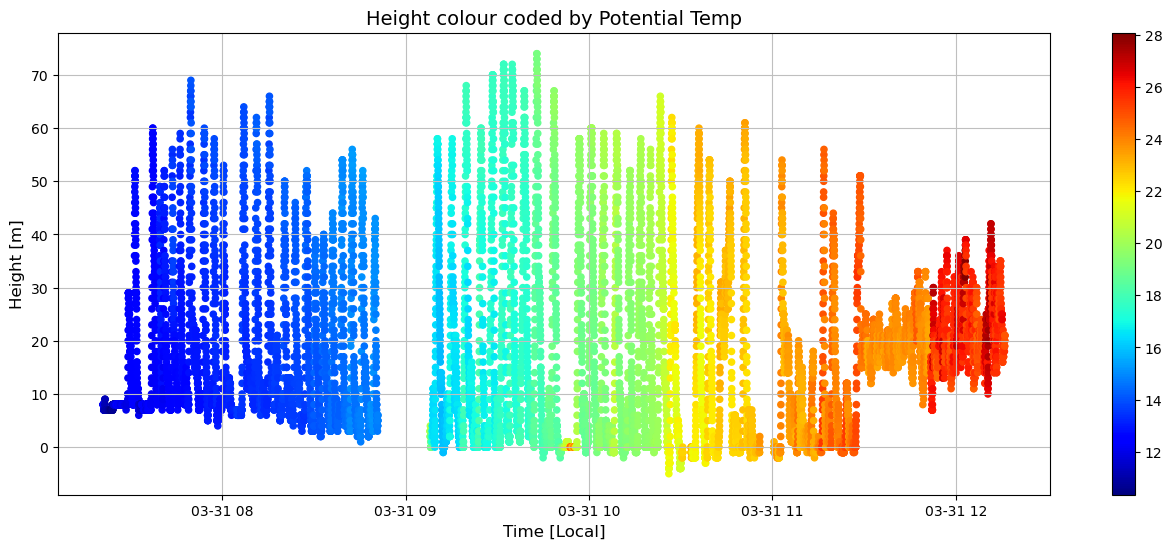

In [15]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values ,data['height_agl_m'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

## Height Correcting
There appears to be drift in the height - this needs to be corrected.


1. First we need to remove the bad data from the end because we don't have any ground reference here.

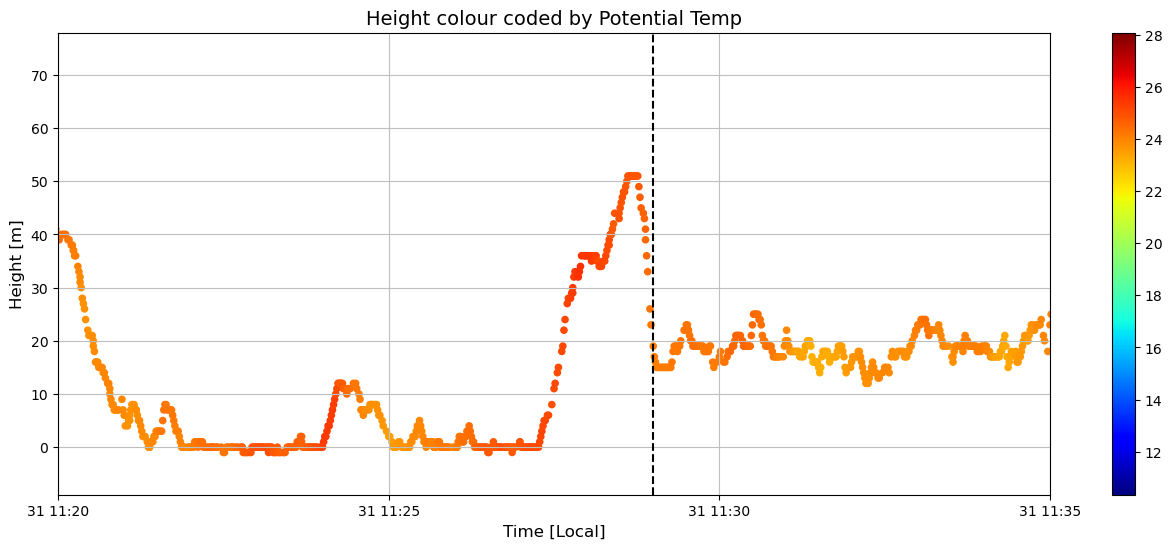

In [16]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values ,data['height_agl_m'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.set_xlim((datetime.datetime(2026,3,31,11,20),datetime.datetime(2026,3,31,11,35)))
#plot cut off for bad time
time_cutoff= datetime.datetime(2026,3,31,11,29)
ax.axvline(time_cutoff,linestyle='--',color='k')
ax.grid(True,linestyle='-',color='0.75')

In [17]:
# Reduce the data
data=data[data.index<time_cutoff]
data.tail(3)

,utc_time,height_msl_m,height_agl_m,pressure,horizontal_speed_mps,heading_deg,temperature,rh,vertical_speed_mps,theta,datetimes_utc
datetimes_local,,,,,,,,,,,
2026-03-31 11:28:55,00:28:55,99,33,101358,2.45,122.10,25.59,44.10,-1.5,24.439757,2026-03-31 00:28:55
2026-03-31 11:28:57,00:28:57,92,26,101440,0.10,125.40,25.52,44.25,-1.9,24.301223,2026-03-31 00:28:57
2026-03-31 11:28:58,00:28:58,89,23,101482,0.10,125.40,25.50,44.30,-2.2,24.246094,2026-03-31 00:28:58


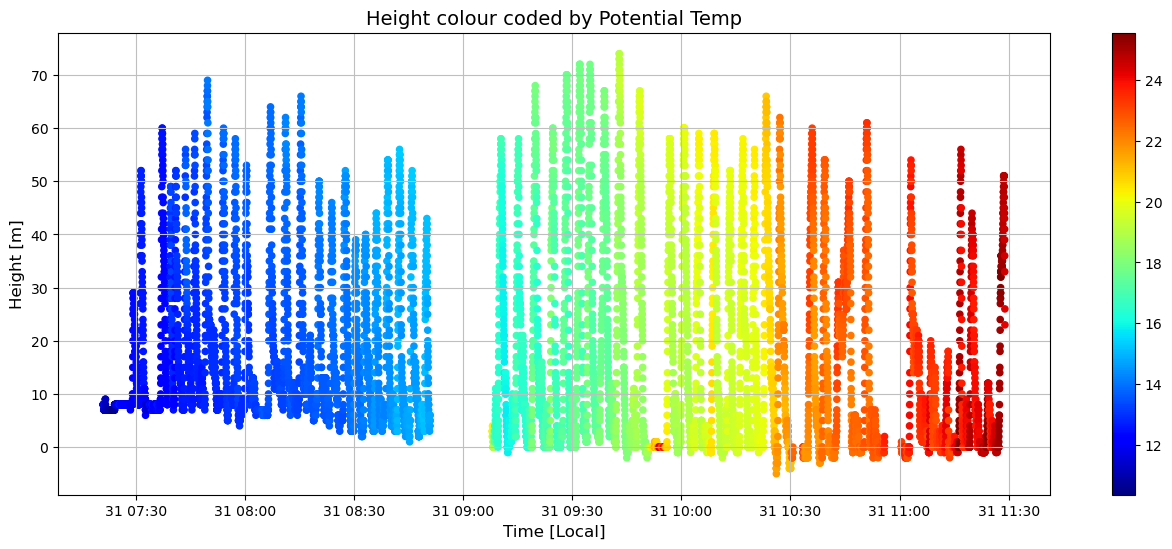

In [18]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values ,data['height_agl_m'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

2. Then we want to take away a 20 minute average

In [19]:
data['height_corrected']=data['height_agl_m']-data['height_agl_m'].resample('20min').transform('min')

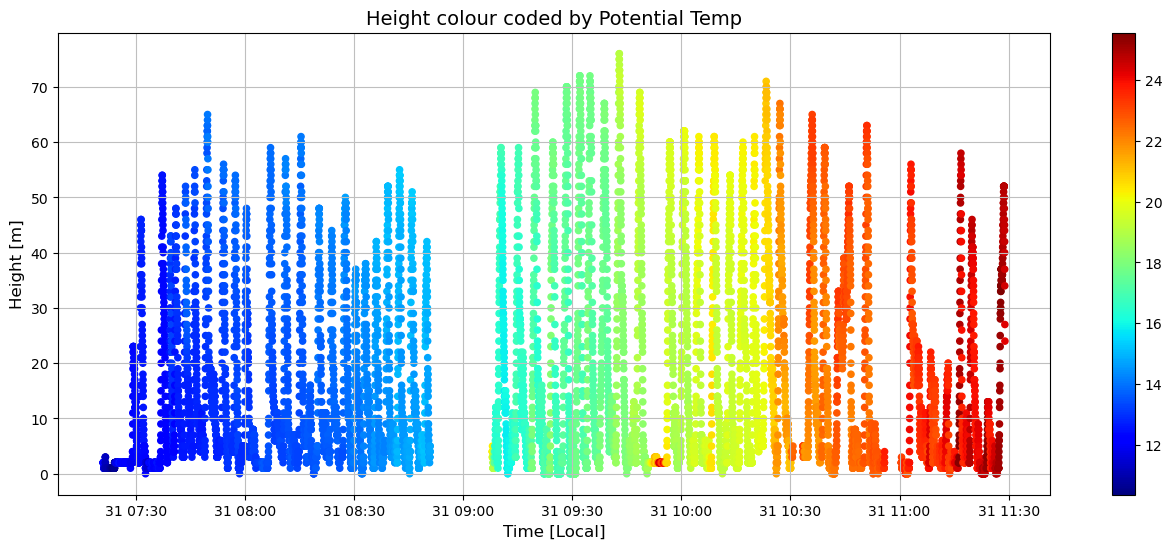

In [20]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values  ,data['height_corrected'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

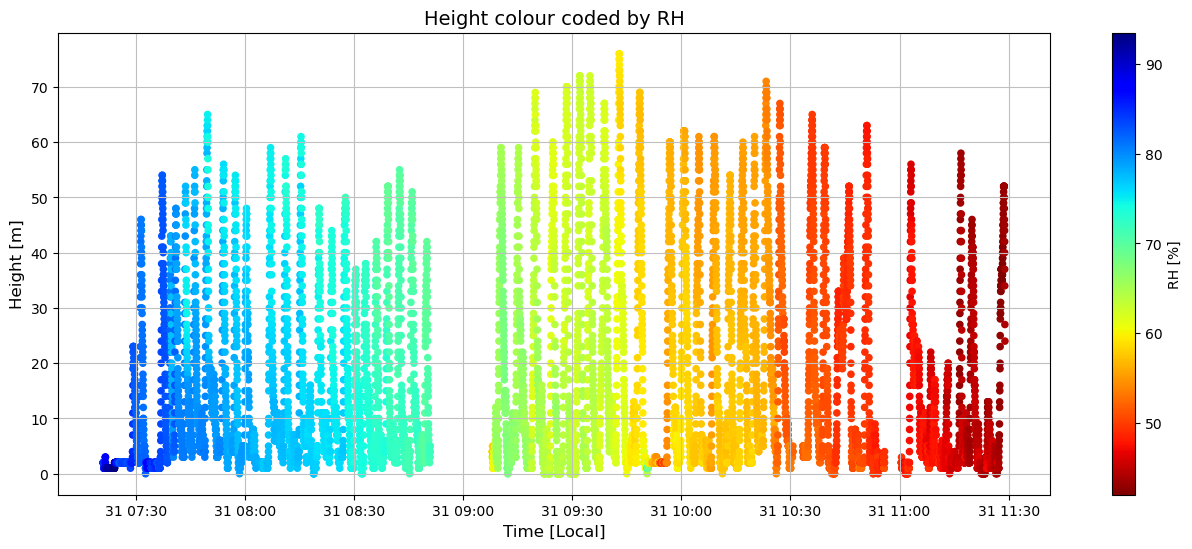

In [21]:
# Now do the same for Relative Humidity
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values, data['height_corrected'].values,s=20,
                c=data['rh'].values.astype(float), marker = 'o', cmap = cm.jet_r );

cbar = plt.colorbar(sc)
cbar.set_label('RH [%]')

# Formatting the plot
ax.set_title("Height colour coded by RH",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

## 20 Minute minimum
You can see the 20 minute minimum here.

<Axes: xlabel='datetimes_local'>

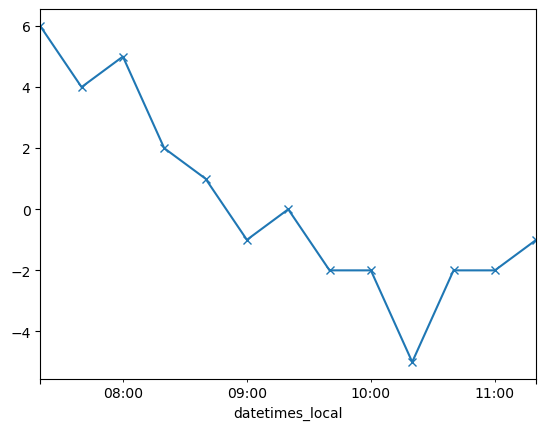

In [22]:
# this line creates a 20 minute average but it is only every 20 minutes
data['height_agl_m'].resample('20min').min().plot(marker='x')


<Axes: xlabel='datetimes_local'>

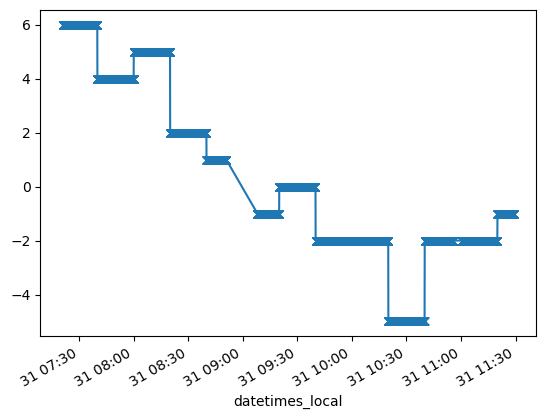

In [23]:
# this code instead applies the minimum value to every second
data['height_agl_m'].resample('20min').transform('min').plot(marker='x')

# Dataset 2: Hand held anemometer data from surface 
Here you can see how we accessed the time series from the kestrel on the oval


In [24]:
## Next read the surface data from the automatic kestral measurements mounted on the side of the cricket pitch
kestrel_auto = pd.read_csv('Oval_Kestrel5400_31_03_2026.csv', header=1,skiprows=[1,2,4])
new_column_names = {
    'FORMATTED DATE_TIME' : 'datetime'
}
kestrel_auto = (kestrel_auto
         .rename(columns=new_column_names) # Rename the columns
         ) 
drop_cols = ["Data Type","Record name","Start time","Duration (H:M:S)","Location description","Location address","Location coordinates","Notes",
            "Crosswind","Headwind","Compass Magnetic Direction","NWB Temp","Compass True Direction"]
kestrel_auto.drop(columns=drop_cols,inplace=True)

In [25]:
kestrel_auto.datetime = pd.to_datetime(kestrel_auto.datetime.values,format='mixed')

In [26]:
kestrel_auto

,datetime,Temperature,Wet Bulb Temp,Globe Temperature,Relative Humidity,Barometric Pressure,Altitude,Station Pressure,Wind Speed,Heat Index,Dew Point,Density Altitude,Thermal Work Limit,Wet Bulb Globe Temperature,Wind Chill
0,2026-03-31 07:33:05,16.2,16.2,12.6,100.0,1017.2,-34,1017.1,0.0,16.8,16.1,73,278.6,15.5,16.1
1,2026-03-31 07:33:07,16.1,16.1,12.6,100.0,1016.9,-32,1016.9,0.0,16.8,16.1,75,279.1,15.4,16.1
2,2026-03-31 07:35:22,16.2,13.9,12.5,78.6,1017.0,-34,1017.1,0.0,15.8,12.4,59,292.6,14.0,16.1
3,2026-03-31 07:40:00,14.2,12.4,12.7,81.8,1017.2,-35,1017.3,3.2,14.0,11.1,-19,320.0,12.7,14.1
4,2026-03-31 07:50:00,14.0,12.1,13.1,80.7,1017.2,-36,1017.3,3.1,13.7,10.7,-27,320.0,12.5,13.9
5,2026-03-31 08:00:00,13.9,12.1,13.4,81.5,1017.5,-36,1017.5,2.7,13.8,10.8,-32,320.0,12.5,13.9
6,2026-03-31 08:10:00,14.1,12.2,13.9,79.7,1017.5,-36,1017.5,2.1,13.9,10.7,-24,320.0,12.8,14.1
7,2026-03-31 08:20:00,14.6,12.4,14.3,78.8,1017.5,-37,1017.6,2.1,14.3,10.9,-9,320.0,12.9,14.5
8,2026-03-31 08:30:00,15.0,12.6,15.7,76.3,1017.7,-39,1017.7,4.6,14.5,10.9,4,320.0,13.5,14.9
9,2026-03-31 08:40:00,15.6,12.8,17.0,73.8,1017.7,-39,1017.7,4.5,15.0,10.9,26,320.0,14.0,15.5


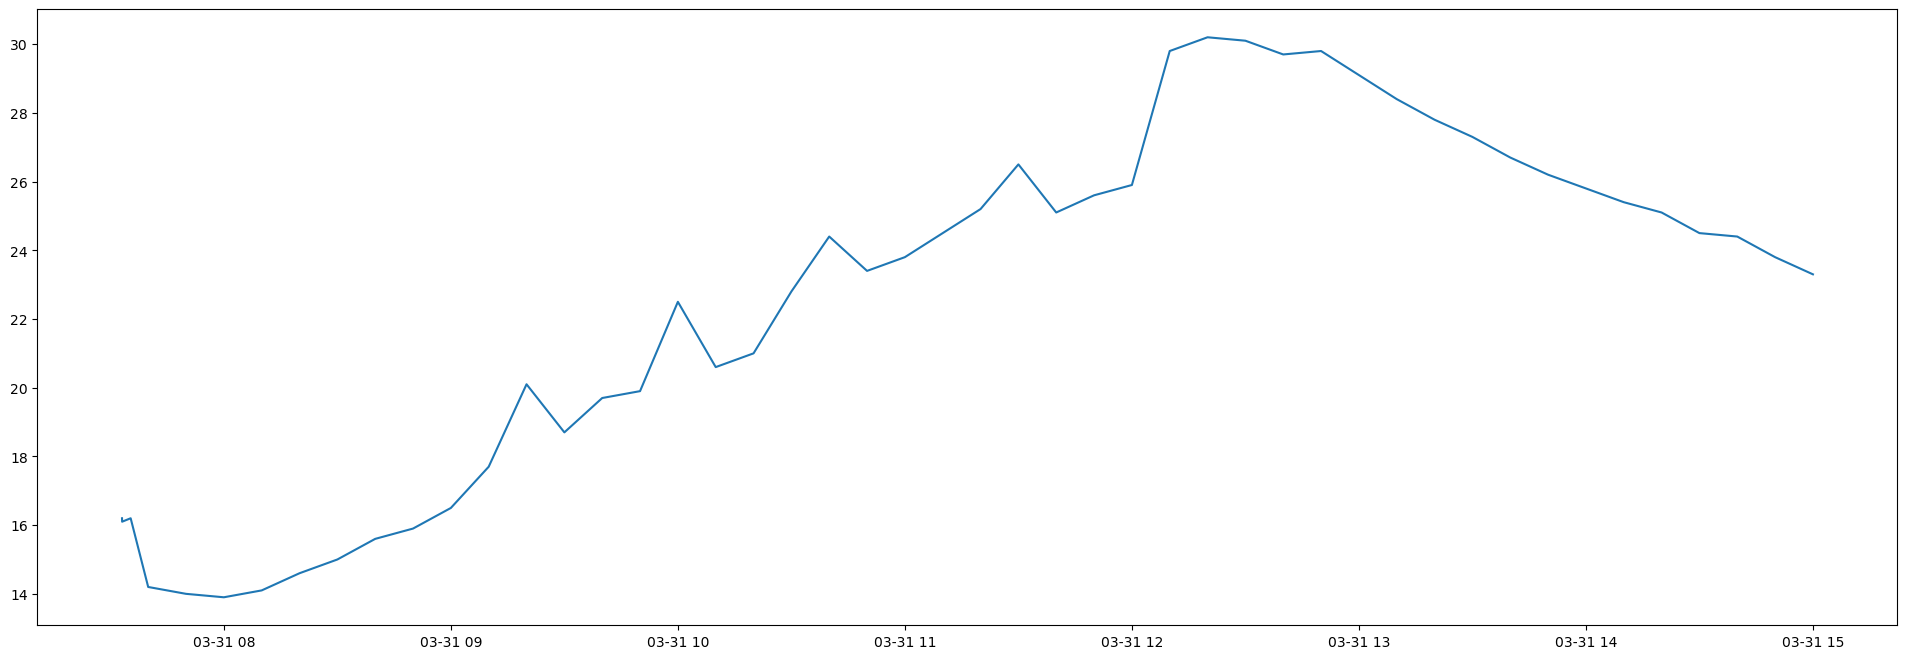

In [27]:
plt.figure(figsize=(24,8))
plt.plot(kestrel_auto.datetime, kestrel_auto.Temperature)

# Dataset 3: Surface Data
Next read the surface data collected on the sports ground

In [28]:
## Next read the surface 10 minute obs (edit this depending on how it ends up getting typed up)
#data3 = pd.read_csv('Surface_data_10min.csv', parse_dates=[['Date', 'Time']])
surface_data = pd.read_csv('Observation_spreadsheet.csv',skiprows=[29,30])
#surface_data = pd.read_csv('Surface_data_10min_2025.csv')

surface_data.head()

,Time,Obs taken by,Cloud oktas,Cloud description,Weather/met obs,Pressure (hPa),Temp (°C),Dewpoint (°C),RH (%),Wind speed (m/s),CO2 (ppm),PM 2.5 (μg/m3),Temp (°C) - from small CO2 sensor,AQI,Voltage
0,7:29,Theo,1.0,"Stratocirrus, stratus",NaN,NaN,10.9,NaN,89.0,NaN,483.0,8.0,10.9,7.0,NaN
1,7:35,Theo,1.0,cirrus,"sun low, no wind gusts",1017.1,16.0,13.8,79.0,2.0,NaN,NaN,NaN,NaN,NaN
2,7:45,Noel,2.0,cirrus,"sun low, no wind gusts, light surface wind",1017.2,14.1,12.2,81.0,1.0,NaN,NaN,NaN,NaN,NaN
3,7:55,Hech,2.0,"cirrus, some stratus","sun risen, no wind gusts",1017.2,13.8,12.0,82.0,0.0,NaN,NaN,NaN,NaN,NaN
4,8:05,Eliza,2.0,"cirrus, some stratus","small light wind gusts, dewy grass",1017.4,14.1,13.9,78.0,1.0,NaN,NaN,NaN,NaN,NaN


In [29]:
pd.to_timedelta(surface_data.Time+":00",errors='coerce')

0    0 days 07:29:00
1    0 days 07:35:00
2    0 days 07:45:00
3    0 days 07:55:00
4    0 days 08:05:00
5    0 days 08:15:00
6    0 days 08:25:00
7    0 days 08:35:00
8    0 days 08:45:00
9    0 days 08:55:00
10   0 days 09:05:00
11   0 days 09:15:00
12   0 days 09:25:00
13   0 days 09:35:00
14   0 days 09:45:00
15   0 days 09:55:00
16   0 days 10:05:00
17   0 days 10:15:00
18   0 days 10:25:00
19   0 days 10:35:00
20   0 days 10:45:00
21   0 days 10:55:00
22   0 days 11:05:00
23   0 days 11:15:00
24   0 days 11:25:00
25   0 days 11:35:00
26   0 days 11:45:00
27   0 days 11:55:00
Name: Time, dtype: timedelta64[ns]

Text(0, 0.5, 'Wind speed [m/s]')

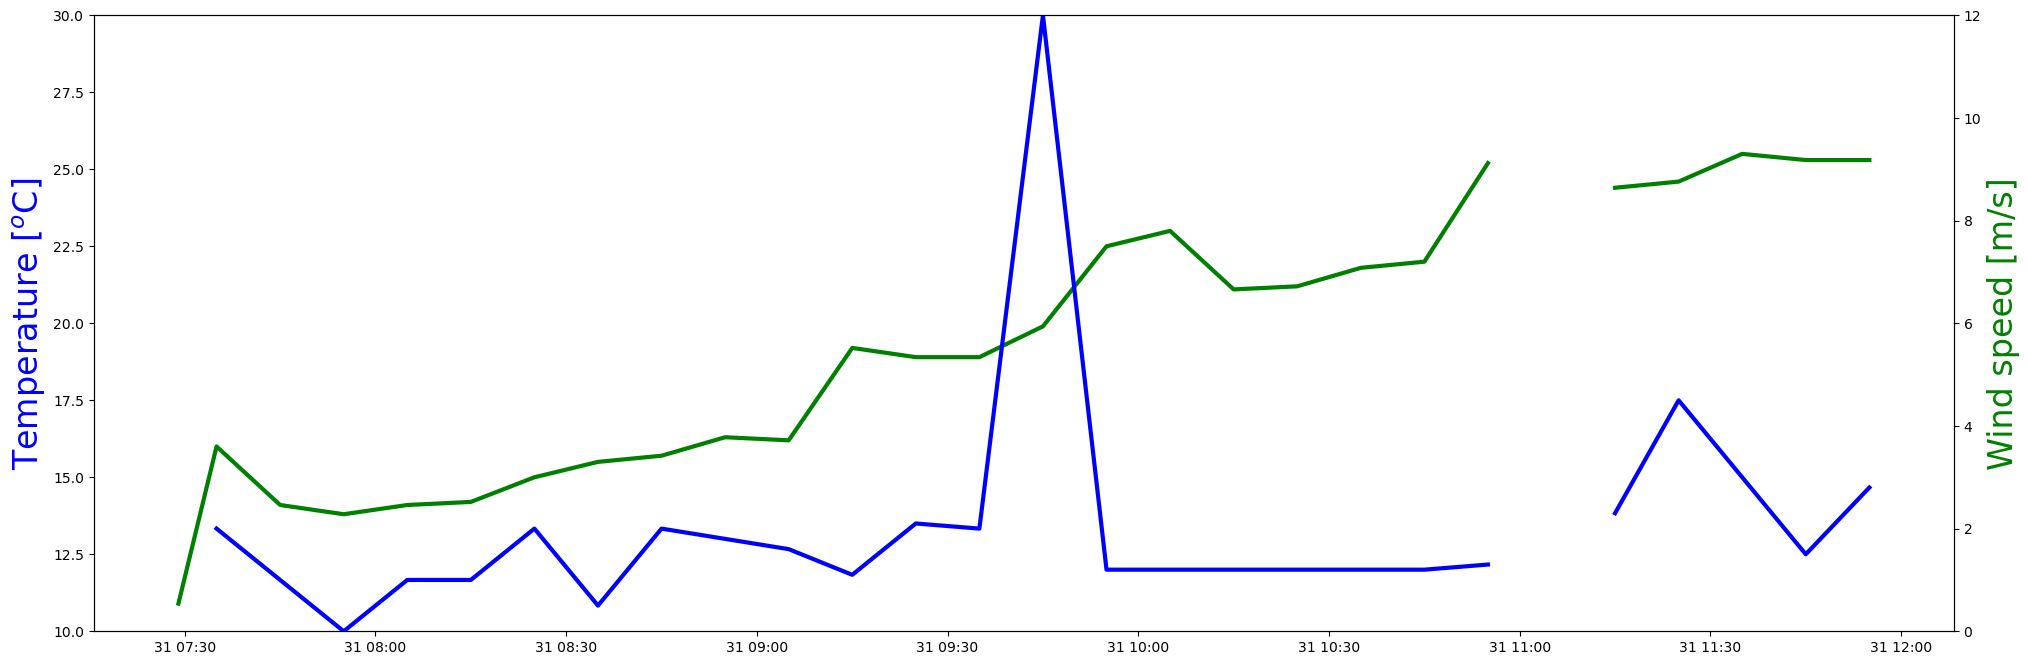

In [30]:
# Here we plot the time series of the data you recorded
# tstart = datetime.datetime(2026, 3, 31, 5, 0, 0)
# tend = datetime.datetime(2026, 3, 31, 12, 0, 0)
time = pd.to_timedelta(surface_data.Time+":00",errors='coerce')+datetime.datetime(2026,3,31,0,0,0)
fig, ax1 = plt.subplots(figsize=(24, 8))

ax2 = ax1.twinx()


ax1.plot(time, surface_data['Temp (°C)'], 'g-', linewidth=3)
ax2.plot(time, surface_data['Wind speed (m/s)'], 'b-', linewidth=3)

# ax1.set_xlim([tstart, tend])
# ax2.set_xlim([tstart, tend])
# ax3.set_xlim([tstart, tend])

ax1.set_ylim([10,30])
ax2.set_ylim([0,12])

ax1.set_ylabel('Temperature [$^o$C]', color='b', fontsize=24)
ax2.set_ylabel('Wind speed [m/s]', color='g', fontsize=24)


# Dataset 4: Data from Redmond Barry Building 
Next read the data from the weather station at the top of Redmond Barry (~50 metres)

In [31]:
# The first 6 rows are metadata
redmond_barry_data = pd.read_csv('AQM65_04112021-856_Data_Export_31-03-2026.csv', skiprows=6)

# The first row is just metadata - select rows 1 onwards (:) and all columns (:)
# redmond_barry_data =redmond_barry_data.iloc[1:, :] 

In [32]:
# The first row is just metadata - select rows 1 onwards (:) and all columns (:)
redmond_barry_data.head(3)

,Time,CO (ppm),NO2 (ppm),NOx (ppm),O3 (ppm),PM2.5 (µg/m³),Ext BC (ng/m³),Ext UVPM (ng/m³),Ext BC(Blue) (ng/m³),Ext BC(Green) (ng/m³),Ext BC(Red) (ng/m³),WS (m/s),WD (°),PRESS (hPa),Pyrano (W/m²),AIR T (°C),AIR RH (%),ITEMP (°C),TEMP (°C),RH (%)
0,30/3/2026 0:00,0.191,0.007,0.011,0.018,0.95,NaN,NaN,NaN,NaN,NaN,0.34,157.0,1009.9,0.8,14.9,85.0,30.0,15.31,82.6
1,30/3/2026 1:00,0.203,0.008,0.014,0.016,1.11,NaN,NaN,NaN,NaN,NaN,0.30,335.2,1009.8,0.8,14.6,85.4,30.0,14.99,83.5
2,30/3/2026 2:00,0.220,0.010,0.015,0.015,1.26,NaN,NaN,NaN,NaN,NaN,0.32,6.0,1009.1,0.8,14.0,87.3,30.0,14.47,85.5


In [33]:
# Rename some columns
new_column_names = {
    # Format is 
    # Old name : new name
    'CO (ppm)': 'CO_ppm',
    'NO2 (ppm)': 'NO2_ppm',
    'NOx (ppm)': 'NOx_ppm',
    'O3 (ppm)': 'O3_ppm',
    'PM2.5 (µg/m³)': 'PM2p5_microgm3',
    'WS (m/s)': 'WS_ms',
    'WD (°)': 'WD_degrees',
    'PRESS (hPa)': 'P_hpa',
    'Pyrano (W/m²)': 'Pyr_wm2',
    'AIR T (°C)': 'T_C',
    'AIR RH (%)':  'RH_pct'
}

In [34]:
redmond_barry_data = (redmond_barry_data
         .rename(columns=new_column_names) # Rename the columns
         .drop(columns=[ 'ITEMP (°C)', 'TEMP (°C)', 'RH (%)']) # Remove these columns
        )

In [35]:
redmond_barry_data.head(3)

,Time,CO_ppm,NO2_ppm,NOx_ppm,O3_ppm,PM2p5_microgm3,Ext BC (ng/m³),Ext UVPM (ng/m³),Ext BC(Blue) (ng/m³),Ext BC(Green) (ng/m³),Ext BC(Red) (ng/m³),WS_ms,WD_degrees,P_hpa,Pyr_wm2,T_C,RH_pct
0,30/3/2026 0:00,0.191,0.007,0.011,0.018,0.95,NaN,NaN,NaN,NaN,NaN,0.34,157.0,1009.9,0.8,14.9,85.0
1,30/3/2026 1:00,0.203,0.008,0.014,0.016,1.11,NaN,NaN,NaN,NaN,NaN,0.30,335.2,1009.8,0.8,14.6,85.4
2,30/3/2026 2:00,0.220,0.010,0.015,0.015,1.26,NaN,NaN,NaN,NaN,NaN,0.32,6.0,1009.1,0.8,14.0,87.3


/var/folders/tq/_30xdh2j4qv6b9jyyd2txc800000gn/T/ipykernel_6731/1344712213.py:12: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ax1.plot(pd.to_datetime(redmond_barry_data.Time), redmond_barry_data.WS_ms, 'g-', linewidth=3)
/var/folders/tq/_30xdh2j4qv6b9jyyd2txc800000gn/T/ipykernel_6731/1344712213.py:13: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ax2.plot(pd.to_datetime(redmond_barry_data.Time), redmond_barry_data.T_C, 'b-', linewidth=3)
/var/folders/tq/_30xdh2j4qv6b9jyyd2txc800000gn/T/ipykernel_6731/1344712213.py:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ax3.plot(pd.to_datetime(redmond_barry_data.Time), redmond_b

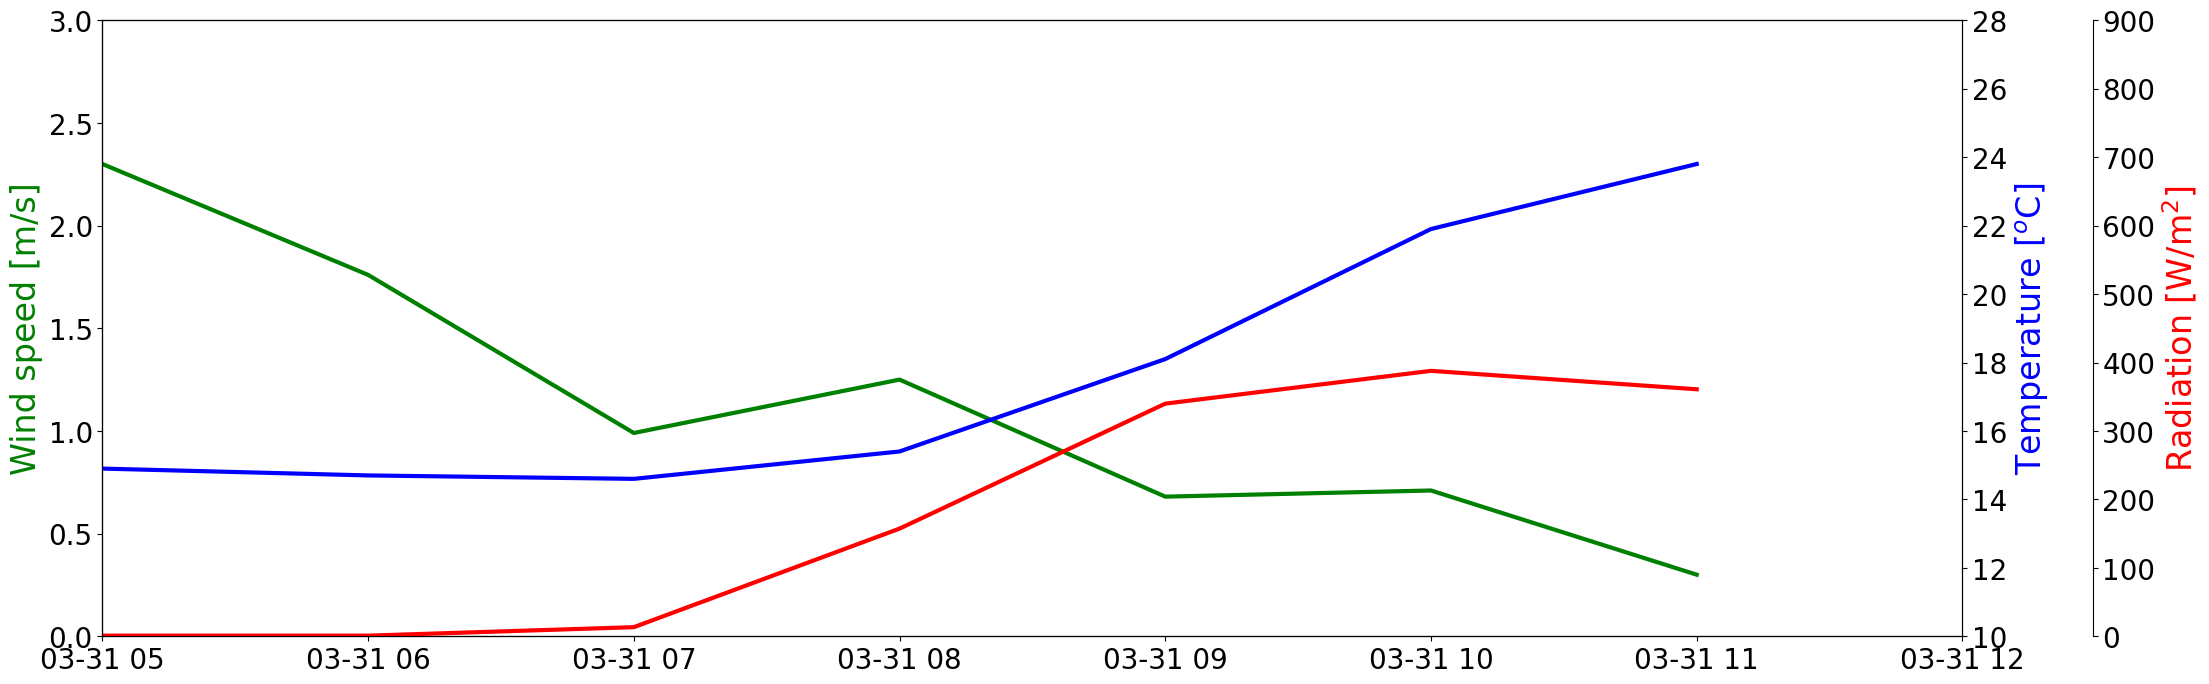

In [36]:
# Here we plot the time series of meteorological data from the top of the Redmond Barry Building
tstart = datetime.datetime(2026, 3, 31, 5, 0, 0)
tend = datetime.datetime(2026, 3, 31, 12, 0, 0)

fig, ax1 = plt.subplots(figsize=(24, 8))

ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines["right"].set_position(("axes", 1.07))

ax1.plot(pd.to_datetime(redmond_barry_data.Time), redmond_barry_data.WS_ms, 'g-', linewidth=3)
ax2.plot(pd.to_datetime(redmond_barry_data.Time), redmond_barry_data.T_C, 'b-', linewidth=3)
ax3.plot(pd.to_datetime(redmond_barry_data.Time), redmond_barry_data.Pyr_wm2, 'r-', linewidth=3)

ax1.set_xlim([tstart, tend])
ax2.set_xlim([tstart, tend])
ax3.set_xlim([tstart, tend])

ax2.set_ylim([10, 28])
ax1.set_ylim([0,3])
ax3.set_ylim([0,900])


ax1.set_ylabel('Wind speed [m/s]', color='g', fontsize=24)
ax2.set_ylabel('Temperature [$^o$C]', color='b', fontsize=24)
ax3.set_ylabel('Radiation [W/m$^2$]', color='r', fontsize=24)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)
ax3.tick_params(labelsize=20)

# Dataset 5: Data from Kestrels
Next read the data from the Kestrel's

Because we have three different datasets that we can't combine, we'll store them inside a dictionary.

In [37]:
kestrel_paths = {"Oval":'Oval_Kestrel5400_31_03_2026.csv',
                 "Dewpoint":'Oval_DewPointKestrel5200_31-03-2026.csv',
                 'Airlab':'Airlab_Kestrel5500_31-03-2026.csv'}
kestrel_names = kestrel_paths.keys()

In [38]:
rename_cols = {"FORMATTED DATE_TIME YYYY-MM-DD HH:MM:SS":"Time"}

In [39]:
kestrel_data = dict()
drop_cols = ["Data Type","Record name","Start time","Duration (H:M:S)","Location description","Location address","Location coordinates","Notes"]
for name, path in kestrel_paths.items():
    df= pd.read_csv(path,header=3)
    df.drop(drop_cols,axis=1,inplace=True)
    df.rename(columns = rename_cols,inplace=True)
    # below is a fancy line to make units look good
    df= df.iloc[1:].set_axis(df.columns + ' ' + df.iloc[0], axis=1)
    df.rename(columns = rename_cols,inplace=True)
    cols = df.columns[1:]
    df[cols]=df[cols].apply(pd.to_numeric,errors="coerce")
    kestrel_data[name] =df.copy()


In [40]:
kestrel_data["Dewpoint"].head(3)

,Time,Temperature °C,Wet Bulb Temp °C,Relative Humidity %,Barometric Pressure mb,Altitude m,Station Pressure mb,Heat Index °C,Dew Point °C,Humidity Ratio g/kg,Density Altitude m,Relative Air Density %,Air Flow m3/m,Air Speed km/h,Evaporation Rate kg/m²/h,Wind Chill °C,Delta T °C,Air Density kg/m3
1,2026-03-31 07:50:00 am,14.4,12.6,81.9,1017.9,-1,1017.9,14.2,11.3,8.30,-17,100.1,0,0.0,0.08,14.3,1.8,1.227
2,2026-03-31 08:00:00 am,13.7,12.1,83.4,1018.0,-2,1018.1,13.6,10.9,8.07,-47,100.4,0,0.0,0.08,13.6,1.6,1.230
3,2026-03-31 08:10:00 am,13.6,12.0,82.5,1018.0,-1,1018.0,13.5,10.7,7.95,-48,100.4,0,0.0,0.08,13.6,1.6,1.230


In [41]:
kestrel_data["Airlab"].head(3)

,Time,Temperature °C,Wet Bulb Temp °C,Relative Humidity %,Barometric Pressure mb,Altitude m,Station Pressure mb,Wind Speed km/h,Heat Index °C,Dew Point °C,Density Altitude m,Crosswind km/h,Headwind km/h,Compass Magnetic Direction Deg,Compass True Direction Deg,Wind Chill °C
1,2026-03-31 07:50:00 am,14.7,12.5,78.6,1017.5,0,1017.5,1.3,14.4,11.0,-2,NaN,NaN,NaN,NaN,14.7
2,2026-03-31 08:00:00 am,15.2,12.3,71.8,1012.5,39,1012.6,0.0,14.6,10.1,61,NaN,NaN,NaN,NaN,15.1
3,2026-03-31 08:10:00 am,15.2,12.3,72.2,1012.5,40,1012.6,0.0,14.7,10.2,63,NaN,NaN,NaN,NaN,15.2


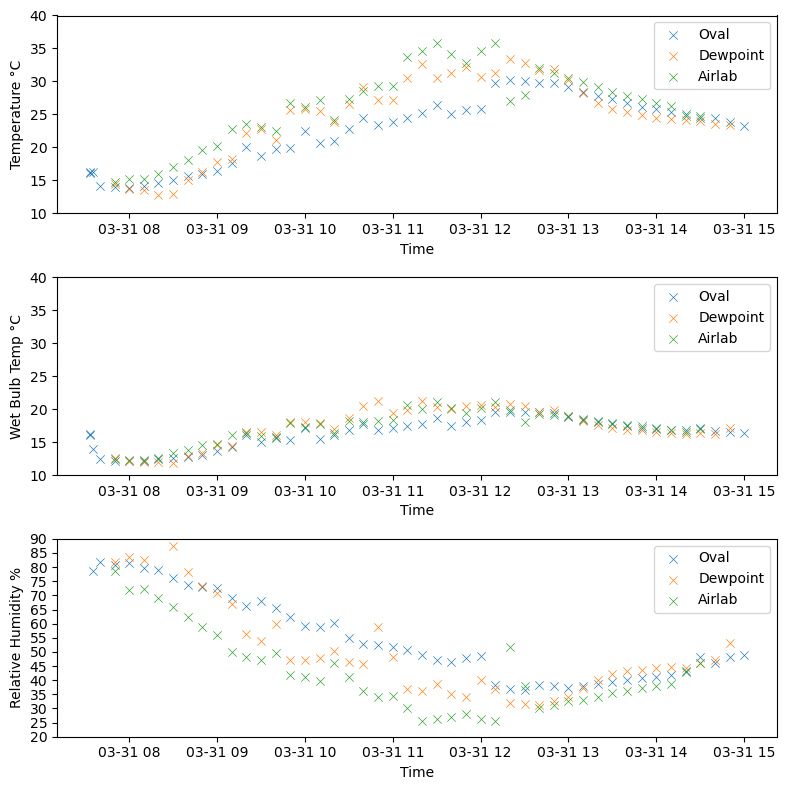

In [42]:
# Here we plot the time series of meteorological data from the top of the Redmond Barry Building
# tstart = datetime.datetime(2026, 3, 31, 5, 0, 0)
# tend = datetime.datetime(2026, 3, 31, 12, 0, 0)
# Get the first and last time values from the index

fig, axs = plt.subplots(3,1,figsize=(8,8))

variables_to_plot = ['Temperature °C','Wet Bulb Temp °C','Relative Humidity %']
y_limits = [(10,40),(10,40),(20,90)]
datasets_to_plot = ['Oval', 'Dewpoint', 'Airlab']

for i,var_ in enumerate(variables_to_plot):
    
    for name,dataset in kestrel_data.items():
        sns.scatterplot(x=pd.to_datetime(dataset.Time,format='mixed'),y=dataset[var_],marker='x',ax=axs[i],label=name)
#         axs[i].tick_params(labelsize=10)
#     axs[i].set_ylabel(var_, fontsize=1)
        axs[i].set_ylim(y_limits[i])
        axs[i].yaxis.set_major_locator(mticker.MultipleLocator(5))

    
plt.tight_layout()
plt.show()


       


# Dataset 6: McCoy Weather Station
We accessed the data from the McCoy weather station for you. There is some really interesting information from here such as wind-direction and solar irradiance. 
A great way to present wind data is a windrose. You can read about them [here](https://en.wikipedia.org/wiki/Wind_rose)

The length of the lines tell you which direction we receive the most wind from, while the size of the colours tell you the distribution of different wind strengths.


In [43]:
#read mccoy data
mccoy_data = pd.read_csv('McCoyBuilding_met_obs_combined.csv', header=0)

# Check columns
mccoy_data.head(3)

,DateTime,Temperature,Dewpoint Temp,Humidity,Atmospheric Pressure,Wind Speed,Wind Direction,Solar Irradiance
0,2026-03-31 00:00:02,17.6,11.6551,68,1014.5,2.91,93.5,-0.835
1,2026-03-31 00:00:12,17.6,11.6551,68,1014.5,3.12,95.4,-0.816
2,2026-03-31 00:00:22,17.5,11.6551,68,1014.5,3.10,86.1,-0.827


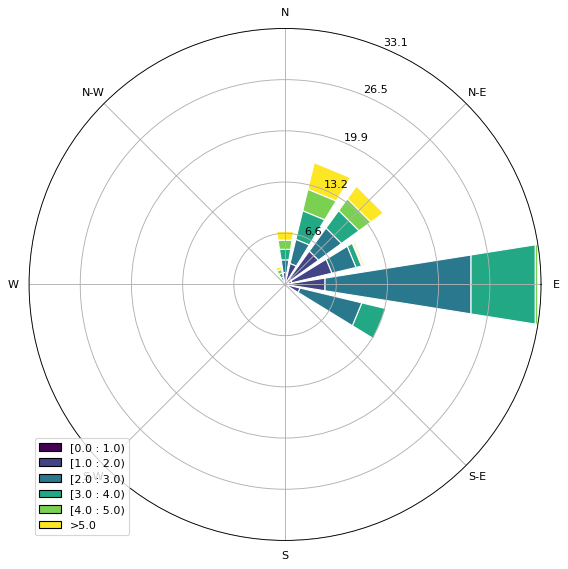

In [44]:
#plot windrose for day
ax = WindroseAxes.from_ax()
wd = mccoy_data['Wind Direction']
ws = mccoy_data['Wind Speed']
bins = np.array([0,1,2,3,4,5])
ax.bar(wd,ws, normed=True, opening=0.8, edgecolor="white",bins=bins)
ax.legend()

### Windrose by hour
The windrose for the day shows that most wind is coming from the east. Having a look at each hour allows us to see how the wind changed across the experiment

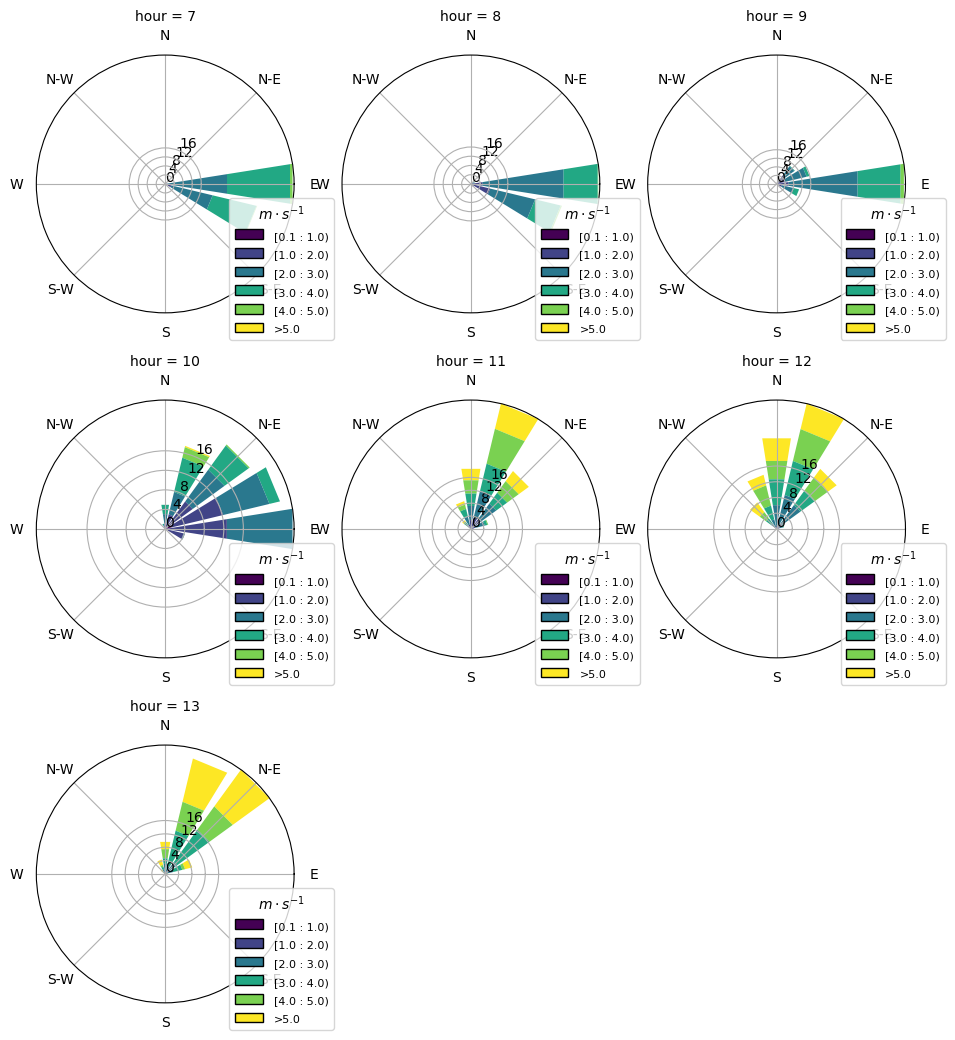

In [45]:
# create 'hour' column
mccoy_data['hour']=pd.to_datetime(mccoy_data['DateTime']).dt.hour
# restrict data from 7 to 1pm
hours = range(7,14)
wind_data = mccoy_data[mccoy_data.hour.isin(hours)]

wind_data = pd.DataFrame(
    {
        "ws":wind_data['Wind Speed'],
        "wd": wind_data['Wind Direction'],
        "hour": wind_data['hour'],
    }
)

# Create function for plotting windroses.
def plot_windrose_subplots(data, *, direction, var, color=None, **kwargs):
    """wrapper function to create subplots per axis"""
    ax = plt.gca()
    ax = WindroseAxes.from_ax(ax=ax)
    plot_windrose(direction_or_df=data[direction], var=data[var], ax=ax, **kwargs)


# this creates the raw subplot structure with a subplot per value in hour.
g = sns.FacetGrid(
    data=wind_data,
    # the column name for each level a subplot should be created
    col="hour",
    # place a maximum of 3 plots per row
    col_wrap=3,
    subplot_kws={"projection": "windrose"},
    sharex=False,
    sharey=False,
    despine=False,
    height=3.5,
)

g.map_dataframe(
    plot_windrose_subplots,
    direction="wd",
    var="ws",
    normed=True,
    # manually set bins, so they match for each subplot
    bins=(0.1, 1, 2, 3, 4, 5),
    calm_limit=0.1,
    kind="bar",
)

# make the subplots easier to compare, by having the same y-axis range
y_ticks = range(0, 17, 4)
for ax in g.axes:
    ax.set_legend(
        title=r"$m \cdot s^{-1}$", bbox_to_anchor=(1.15, -0.1), loc="lower right"
    )
    ax.set_rgrids(y_ticks, y_ticks)

# adjust the spacing between the subplots to have sufficient space between plots
plt.subplots_adjust(wspace=-0.2)

Now we can see that the wind changed in direction and strength over the day

### Solar Irrandiance
Below we've plotted a simple lineplot of the solar irradiance accross the whole day

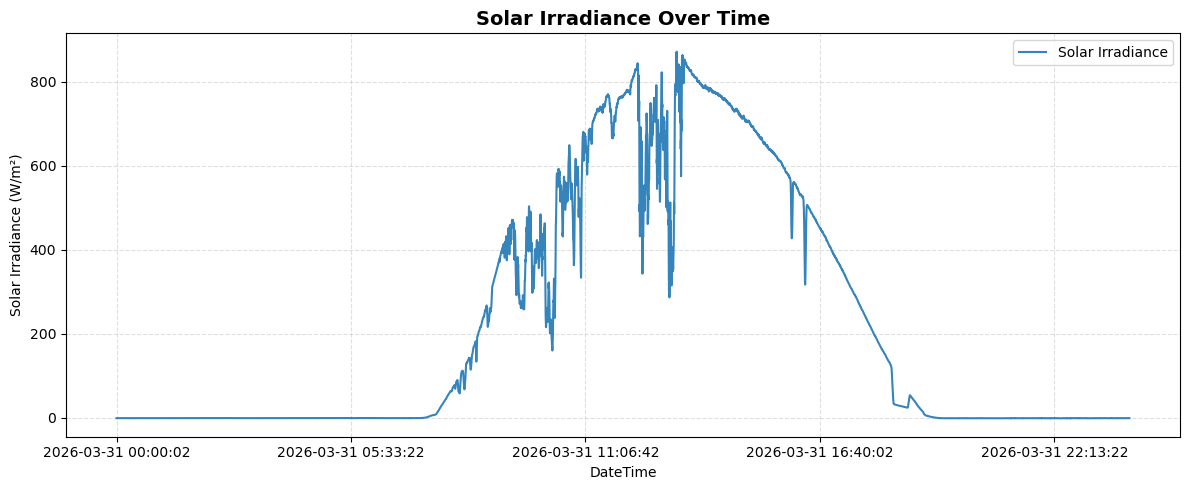

In [46]:

fig, ax = plt.subplots(figsize=(12, 5))

mccoy_data.plot(
        x='DateTime',
        y='Solar Irradiance',
    linewidth=1.5,
    alpha=0.9,ax=ax
)

ax.set_title('Solar Irradiance Over Time', fontsize=14, weight='bold')
# ax.set_xlabel('Time')
ax.set_ylabel('Solar Irradiance (W/m²)')

ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()